In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/Users/bhijanbastola/Desktop/intern/Data/diabetes_prediction_dataset.csv")

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
df.smoking_history.unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

<Axes: xlabel='age', ylabel='bmi'>

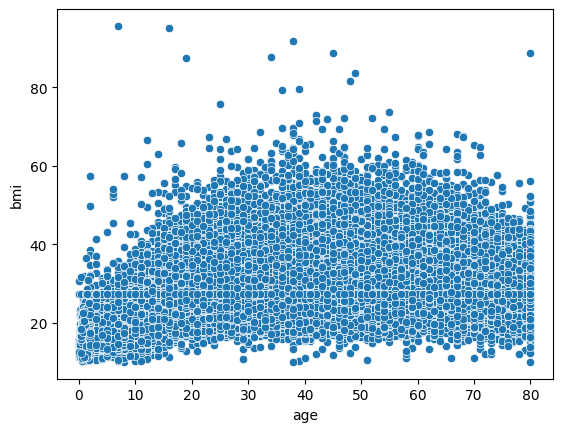

In [5]:
sns.scatterplot(df,x="age",y="bmi")

<Axes: >

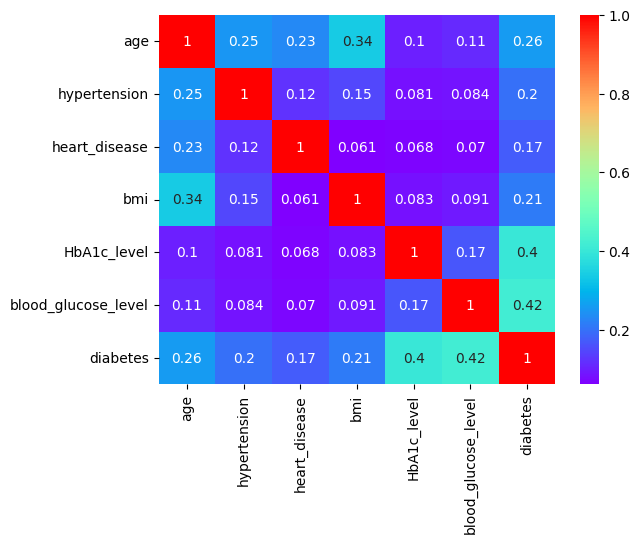

In [6]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="rainbow")

/var/folders/0j/c86nz3417lg1_k7f7zrhm97h0000gn/T/ipykernel_18638/1828909244.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='diabetes', ylabel='HbA1c_level'>

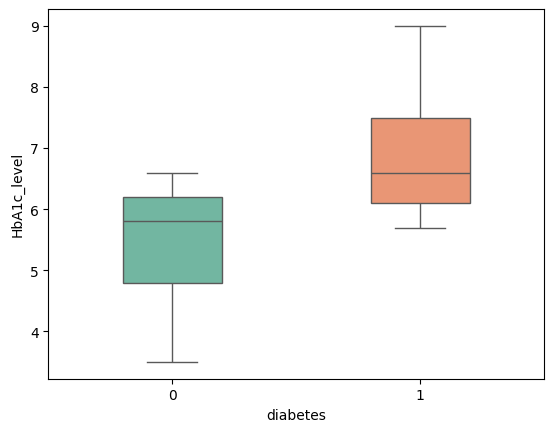

In [7]:
sns.boxplot(
    data=df,
    x="diabetes",
    y="HbA1c_level",
    palette="Set2",
    
    width=0.4,)

/var/folders/0j/c86nz3417lg1_k7f7zrhm97h0000gn/T/ipykernel_18638/3321079930.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='diabetes', ylabel='blood_glucose_level'>

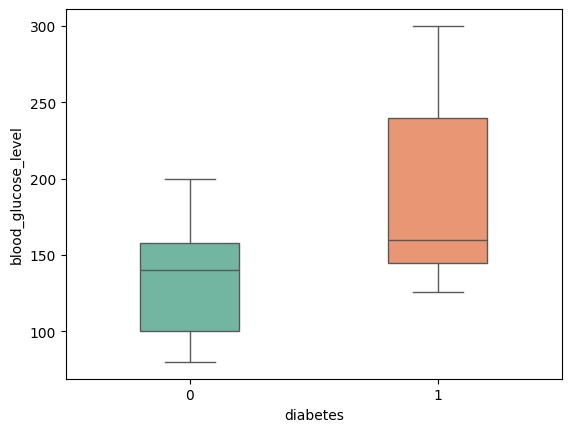

In [8]:
sns.boxplot(
    data=df,
    x="diabetes",
    y="blood_glucose_level",
    palette="Set2",
    
    width=0.4,
)

<Axes: xlabel='blood_glucose_level', ylabel='Count'>

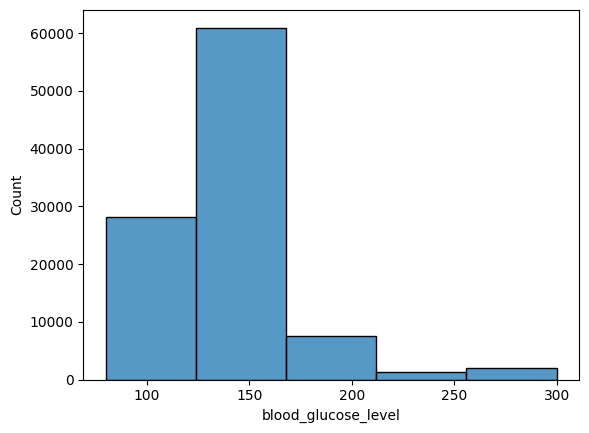

In [9]:
sns.histplot(df,x="blood_glucose_level",bins=5)

<Axes: xlabel='age', ylabel='bmi'>

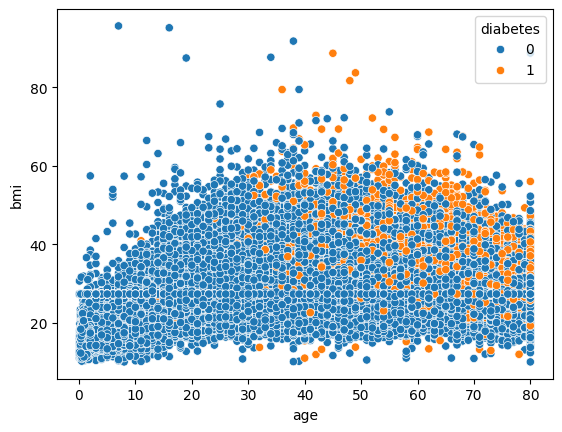

In [10]:
sns.scatterplot(df,x="age",y="bmi",hue="diabetes")

In [11]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(3854)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.smoking_history.replace({"never":0,"No Info":0,"current":1,"former":2,"ever":3},inplace=True)

/var/folders/0j/c86nz3417lg1_k7f7zrhm97h0000gn/T/ipykernel_18638/434209959.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.smoking_history.replace({"never":0,"No Info":0,"current":1,"former":2,"ever":3},inplace=True)


In [16]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,0,25.19,6.6,140,0
1,Female,54.0,0,0,0,27.32,6.6,80,0
2,Male,28.0,0,0,0,27.32,5.7,158,0
3,Female,36.0,0,0,1,23.45,5.0,155,0
4,Male,76.0,1,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,0,24.60,4.8,145,0
99996,Female,2.0,0,0,0,17.37,6.5,100,0
99997,Male,66.0,0,0,2,27.83,5.7,155,0
99998,Female,24.0,0,0,0,35.42,4.0,100,0


In [17]:
df.gender.value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

In [18]:
df.gender.replace({"Female":0,
               "Male":1,
               "Other":2},inplace=True)

/var/folders/0j/c86nz3417lg1_k7f7zrhm97h0000gn/T/ipykernel_18638/1362623375.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.gender.replace({"Female":0,
/var/folders/0j/c86nz3417lg1_k7f7zrhm97h0000gn/T/ipykernel_18638/1362623375.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.gender.rep

In [19]:
bins = [0, 18.5, 25, 30, float("inf")]
labels = ["Underweight", "Normal", "Overweight", "Obese"]

df["bmi_categorical"] = pd.cut(
    df["bmi"],
    bins=bins,
    labels=labels,
    right=False
)

In [20]:
df.drop(columns="bmi",inplace=True)

In [21]:
df

,gender,age,hypertension,heart_disease,smoking_history,HbA1c_level,blood_glucose_level,diabetes,bmi_categorical
0,0,80.0,0,1,0,6.6,140,0,Overweight
1,0,54.0,0,0,0,6.6,80,0,Overweight
2,1,28.0,0,0,0,5.7,158,0,Overweight
3,0,36.0,0,0,1,5.0,155,0,Normal
4,1,76.0,1,1,1,4.8,155,0,Normal
...,...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,0,4.8,145,0,Normal
99996,0,2.0,0,0,0,6.5,100,0,Underweight
99997,1,66.0,0,0,2,5.7,155,0,Overweight
99998,0,24.0,0,0,0,4.0,100,0,Obese


In [22]:
df.gender.value_counts()

gender
0    56161
1    39967
2       18
Name: count, dtype: int64

In [35]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,confusion_matrix
from sklearn.model_selection import train_test_split

X=df.drop(columns="diabetes",axis=1)
y=df["diabetes"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42,stratify=y)

In [25]:

ordinal_cols = ["bmi_categorical","HbA1c_level","blood_glucose_level","age"]
onehot_cols = ["gender","hypertension","heart_disease"]

In [26]:
ordinal_encoder = OrdinalEncoder()

X_train[ordinal_cols] = ordinal_encoder.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols] = ordinal_encoder.transform(X_test[ordinal_cols])

In [27]:
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")


X_train_encoded = onehot_encoder.fit_transform(X_train[onehot_cols])

X_test_encoded = onehot_encoder.transform(X_test[onehot_cols])

# Convert to DataFrame
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=onehot_encoder.get_feature_names_out(onehot_cols),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=onehot_encoder.get_feature_names_out(onehot_cols),
    index=X_test.index
)

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded,
    y_train
)

In [31]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
diabetes
0    70130
1     6786
Name: count, dtype: int64

After SMOTE:
diabetes
0    70130
1    70130
Name: count, dtype: int64


In [ ]:
model=LogisticRegression().fit(X_train_smote,y_train_smote)
y_pred=model.predict(X_test_encoded)

In [43]:

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))
     
 

    

0.8639105564222569
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     17534
           1       0.28      0.34      0.30      1696

    accuracy                           0.86     19230
   macro avg       0.61      0.63      0.61     19230
weighted avg       0.88      0.86      0.87     19230



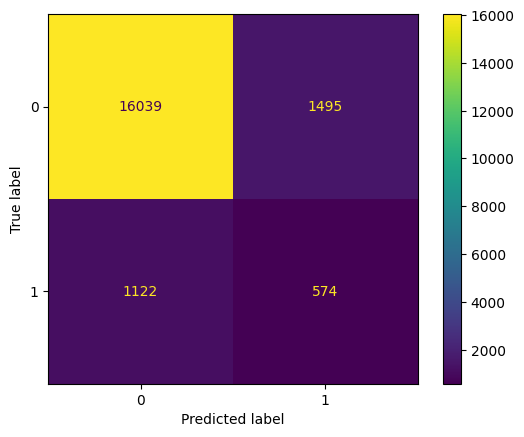

In [47]:
cm=confusion_matrix(y_test,y_pred,labels=model.classes_)
cmd=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
cmd.plot()
plt.show()